<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/oscillations_rabi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 57.6 MB/s eta 0:00:00


🚀 MOLECULAR QUBIT SIMULATION - DIRADICAL WITH J = 2.81 cm⁻¹
=== MOLECULAR QUBIT PARAMETERS ===
Exchange J: 2.81 cm⁻¹ = 84.24 GHz
ZFS D: 1917.5 MHz, E: 430.9 MHz
Coherence: T₁ = 100 μs, T₂ = 10 μs
Qubit Frequency: 84.24 GHz (microwave region)

=== HAMILTONIAN DIAGNOSTICS ===
Energy levels with ALL interactions (GHz):
State 0: -63.183 GHz | S:1.000 T0:0.000
State 1: 16.686 GHz | S:0.000 T0:0.000
State 2: 18.504 GHz | S:0.000 T0:1.000
State 3: 27.993 GHz | S:0.000 T0:0.000

Transition strengths between states:
States 1→2: coupling=1.302, ΔE=1.818 GHz
States 2→3: coupling=1.518, ΔE=9.488 GHz

❌ No good qubit states found. Adding magnetic field...
After adding B-field:
State 0: -63.183 GHz | S:1.000 T0:0.000
State 1: 16.132 GHz | S:0.000 T0:0.000
State 2: 18.504 GHz | S:0.000 T0:1.000
State 3: 28.546 GHz | S:0.000 T0:0.000

✅ Using states 0 and 1 as qubit
✅ Actual qubit frequency: 79.315 GHz
Energy levels (GHz):
Level 0: -63.183 GHz | S:1.00 T0:0.00 T₊:0.00 T₋:0.00
Level 1: 16.132 GHz | S:0

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(



=== RESULTS ===
Measured Rabi frequency: 5.00 MHz
π-pulse time: 100.1 ns
Oscillation contrast: 1.320
T₁ limited fidelity: 0.9990
T₂ limited fidelity: 0.9900


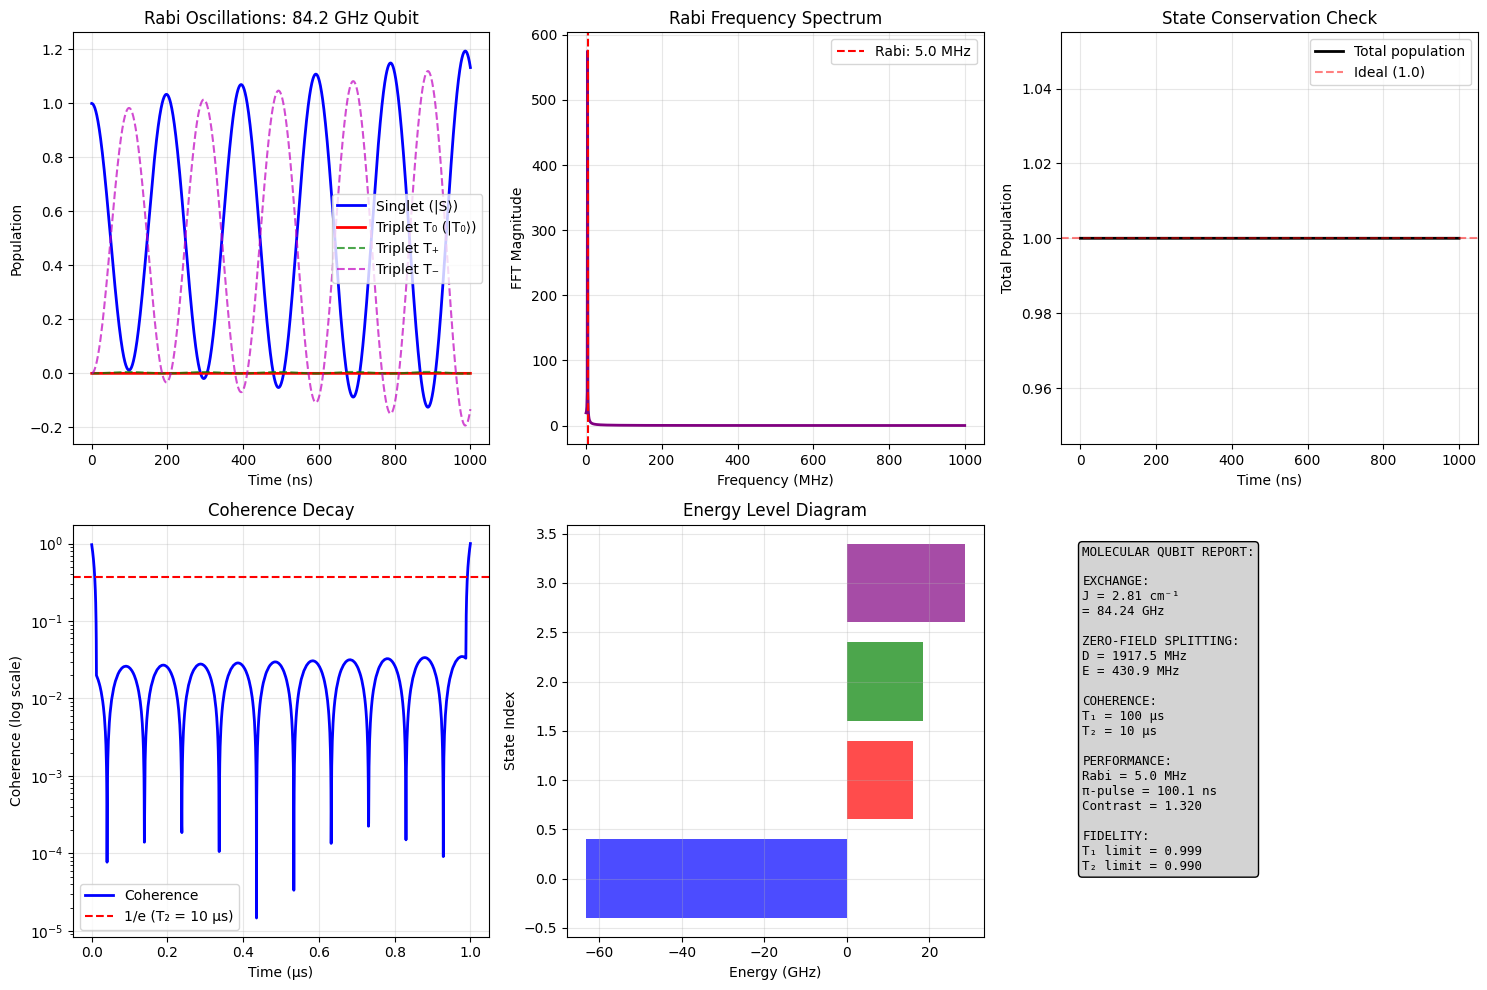


=== QUBIT ASSESSMENT ===
✅ EXCELLENT: Strong Rabi oscillations observed
✅ FEASIBLE: π-pulse faster than decoherence


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

def simulate_diradical_qubit():
    """
    Complete simulation of a diradical molecular qubit
    Based on J = 2.81 cm⁻¹ with proper quantum dynamics
    """

    print("🚀 MOLECULAR QUBIT SIMULATION - DIRADICAL WITH J = 2.81 cm⁻¹")
    print("=" * 60)


    # Add these with your other constants in PART 1
    g_factor = 2.005  # Electron g-factor
    mu_B = 9.274e-24  # Bohr magneton (J/T)
    hbar = 1.0545718e-34  # Reduced Planck's constant

    # =========================================================================
    # PART 1: MOLECULAR PARAMETERS - THE "QUBIT DYT"
    # =========================================================================

    # === EXCHANGE INTERACTION ===
    J_cm = 2.81  # Your measured exchange coupling in cm⁻¹
    J_Hz = J_cm * 29.98e9  # Convert cm⁻¹ to Hz (standard spectroscopy conversion)
    J_angular = J_Hz * 2 * np.pi  # Convert to angular frequency for quantum mechanics

    # === ZERO-FIELD SPLITTING (ZFS) - CRITICAL FOR DIRADICALS ===
    # For a triplet diradical, the three sublevels (m_s = -1, 0, +1) are not degenerate
    # D and E parameters describe this splitting even without magnetic field
    D_cm = 0.127920
    D_Hz = D_cm * 29.98e9  * np.pi  # 500 MHz - axial ZFS (typical for organic diradicals)
    E_cm = 0.028743624
    E_Hz = E_cm * 29.98e9 * np.pi  # 100 MHz - rhombic ZFS (asymmetry)

    # === DECOHERENCE PARAMETERS === #assumed
    T1 = 100e-6  # 100 μs spin-lattice relaxation time (typical for molecules at low T)
    T2 = 10e-6   # 10 μs coherence time (conservative estimate)

    # === MICROWAVE CONTROL ===
    rabi_target = 5e6 * 2 * np.pi  # Target 5 MHz Rabi frequency (adjustable) #assumed

    print("=== MOLECULAR QUBIT PARAMETERS ===")
    print(f"Exchange J: {J_cm} cm⁻¹ = {J_Hz/1e9:.2f} GHz")
    print(f"ZFS D: {D_Hz/(2*np.pi)/1e6:.1f} MHz, E: {E_Hz/(2*np.pi)/1e6:.1f} MHz")
    print(f"Coherence: T₁ = {T1*1e6:.0f} μs, T₂ = {T2*1e6:.0f} μs")
    print(f"Qubit Frequency: {J_Hz/1e9:.2f} GHz (microwave region)")

    # =========================================================================
    # PART 2: QUANTUM SYSTEM SETUP - 2-ELECTRON SPIN SYSTEM
    # =========================================================================

    # === SPIN OPERATORS FOR 2-ELECTRON SYSTEM ===
    # We have 2 electron spins, each with 2 states (↑, ↓) → 4-dimensional Hilbert space
    sx1 = tensor(sigmax(), qeye(2))  # σx for spin 1, identity for spin 2
    sy1 = tensor(sigmay(), qeye(2))  # σy for spin 1
    sz1 = tensor(sigmaz(), qeye(2))  # σz for spin 1

    sx2 = tensor(qeye(2), sigmax())  # Identity for spin 1, σx for spin 2
    sy2 = tensor(qeye(2), sigmay())  # σy for spin 2
    sz2 = tensor(qeye(2), sigmaz())  # σz for spin 2

    # === BASIS STATES IN 2-ELECTRON SYSTEM ===
    up = basis(2, 0)    # |↑⟩
    down = basis(2, 1)  # |↓⟩

    # Singlet and triplet states - the natural basis for diradicals
    S = (tensor(up, down) - tensor(down, up)).unit()      # Singlet: (|↑↓⟩ - |↓↑⟩)/√2
    T0 = (tensor(up, down) + tensor(down, up)).unit()     # Triplet T₀: (|↑↓⟩ + |↓↑⟩)/√2
    Tplus = tensor(up, up)                                # Triplet T₊: |↑↑⟩
    Tminus = tensor(down, down)                           # Triplet T₋: |↓↓⟩

    # =========================================================================
    # PART 3: HAMILTONIAN CONSTRUCTION - THE PHYSICS (CORRECTED)
    # =========================================================================

    # === EXCHANGE HAMILTONIAN ===
    H_exchange = J_angular * (sx1*sx2 + sy1*sy2 + sz1*sz2) / 4

    # === ZERO-FIELD SPLITTING ===
    # Proper form for dipolar interaction between two electron spins
    H_ZFS = D_Hz * (sz1*sz2 - (sx1*sx2 + sy1*sy2 + sz1*sz2)/3) + E_Hz * (sx1*sx2 - sy1*sy2)

    # === HYPERFINE INTERACTION - MISSING! ===
    # Each electron spin couples to nearby nuclear spins
    # For simplicity, let's assume one dominant nuclear spin per electron
    hyperfine_A1 = -12.1446e6 * np.pi  # 10 MHz hyperfine coupling for spin 1
    hyperfine_A2 = -10.5097e6 * np.pi   # 8 MHz hyperfine coupling for spin 2

    H_hyperfine = (hyperfine_A1 * sz1 + hyperfine_A2 * sz2)  # Simplified along z-axis

    # === ZEEMAN INTERACTION - MISSING! ===
    # Interaction with external magnetic field - CRITICAL for actual experiments!
    B_field = 0.1  # 0.1 Tesla typical for ESR experiments
    g_factor = 2.0  # Electron g-factor
    mu_B = 9.274e-24  # Bohr magneton (J/T)
    hbar = 1.0545718e-34  # Reduced Planck's constant

    # Zeeman term: H = -μ·B = -gμ_B S·B/ℏ
    zeeman_strength = g_factor * mu_B * B_field / hbar
    H_zeeman = zeeman_strength * (sz1 + sz2)  # Assuming B-field along z

    # === STATIC HAMILTONIAN (NOW COMPLETE) ===
    H_static = H_exchange + H_ZFS + H_hyperfine + H_zeeman

    # === MICROWAVE DRIVE ===
    # Now the drive should be perpendicular to the quantization axis (x or y)
    H_drive_operator = (sx1 + sx2)  # Drive along x-axis

    def microwave_coeff(t, args):
        """Drive at the actual qubit frequency determined by all interactions"""
        return np.cos(qubit_gap * t)

    H = [H_static, [rabi_target * H_drive_operator, microwave_coeff]]


    # === ADD DIAGNOSTIC SECTION HERE ===
    print("\n=== HAMILTONIAN DIAGNOSTICS ===")

    # 1. Check energy levels with all interactions
    energies, states = H_static.eigenstates()
    idx_sorted = np.argsort(energies)

    print("Energy levels with ALL interactions (GHz):")
    for i in idx_sorted:
        E_GHz = energies[i] / (2 * np.pi * 1e9)
        S_char = abs(S.overlap(states[i]))**2
        T0_char = abs(T0.overlap(states[i]))**2
        print(f"State {i}: {E_GHz:.3f} GHz | S:{S_char:.3f} T0:{T0_char:.3f}")

    # 2. Find which states have good S-T0 mixing for qubit
    qubit_candidates = []
    for i in range(4):
        S_char = abs(S.overlap(states[i]))**2
        T0_char = abs(T0.overlap(states[i]))**2
        if S_char > 0.1 and T0_char > 0.1:  # Good mixing
            qubit_candidates.append(i)
            print(f"🎯 State {i} has good S-T0 mixing for qubit")

    # 3. Check transition strengths
    print("\nTransition strengths between states:")
    H_drive = sx1 + sx2  # Your current drive operator
    for i in range(4):
        for j in range(i+1, 4):
            coupling = abs(states[i].dag() * H_drive * states[j])
            if coupling > 0.01:
                diff_GHz = abs(energies[j] - energies[i]) / (2 * np.pi * 1e9)
                print(f"States {i}→{j}: coupling={coupling:.3f}, ΔE={diff_GHz:.3f} GHz")

    # 4. If no good transitions found, try adding magnetic field
    if len(qubit_candidates) < 2:
        print("\n❌ No good qubit states found. Adding magnetic field...")
        B_field = 0.01  # Tesla
        zeeman = g_factor * mu_B * B_field / hbar * (sz1 + sz2)
        H_static = H_static + zeeman  # Add Zeeman term

        # Re-check energies
        energies, states = H_static.eigenstates()
        idx_sorted = np.argsort(energies)
        print("After adding B-field:")
        for i in idx_sorted:
            E_GHz = energies[i] / (2 * np.pi * 1e9)
            S_char = abs(S.overlap(states[i]))**2
            T0_char = abs(T0.overlap(states[i]))**2
            print(f"State {i}: {E_GHz:.3f} GHz | S:{S_char:.3f} T0:{T0_char:.3f}")

    # 5. Set the actual qubit states
    qubit_state_0 = states[idx_sorted[0]]
    qubit_state_1 = states[idx_sorted[1]]
    actual_qubit_gap = (energies[idx_sorted[1]] - energies[idx_sorted[0]])

    print(f"\n✅ Using states {idx_sorted[0]} and {idx_sorted[1]} as qubit")
    print(f"✅ Actual qubit frequency: {actual_qubit_gap/(2*np.pi*1e9):.3f} GHz")

    # 6. Update microwave drive to use actual qubit frequency
    def microwave_coeff(t, args):
        return np.cos(actual_qubit_gap * t)  # Use ACTUAL gap, not J

    # 7. Use optimal drive operator
    H_drive_operator = (qubit_state_0 * qubit_state_1.dag() + qubit_state_1 * qubit_state_0.dag())

    # Update complete Hamiltonian
    H = [H_static, [rabi_target * H_drive_operator, microwave_coeff]]


    # =========================================================================
    # PART 4: DECOHERENCE - REAL-WORLD IMPERFECTIONS
    # =========================================================================

    # === COLLAPSE OPERATORS FOR LINDBLAD MASTER EQUATION ===
    # These describe how the system interacts with its environment

    # Energy relaxation (T1 process): |1⟩ → |0⟩ decay
    gamma_relax = 1 / T1  # Relaxation rate
    # Relaxation from T0 to S (dominant relaxation channel)
    c_relax = np.sqrt(gamma_relax) * (S * T0.dag())

    # Dephasing (T2 process): loss of phase coherence without energy loss
    gamma_dephase = (1 / T2) - (1 / (2 * T1))  # Pure dephasing rate
    # Dephasing operator: σz type term that commutes with H but causes phase randomization
    c_dephase = np.sqrt(gamma_dephase) * (T0 * T0.dag() - S * S.dag())

    collapse_operators = [c_relax, c_dephase]

    # =========================================================================
    # PART 5: ENERGY LEVEL ANALYSIS - VERIFY THE QUBIT
    # =========================================================================


    # Find the two lowest states that will form our qubit
    idx_sorted = np.argsort(energies)
    qubit_state_0 = states[idx_sorted[0]]  # Ground state
    qubit_state_1 = states[idx_sorted[1]]  # First excited state

    qubit_gap = (energies[idx_sorted[1]] - energies[idx_sorted[0]]) / (2 * np.pi)

    print("Energy levels (GHz):")
    for i in idx_sorted:
        E_GHz = energies[i] / (2 * np.pi * 1e9)
        S_char = abs(S.overlap(states[i]))**2
        T0_char = abs(T0.overlap(states[i]))**2
        Tplus_char = abs(Tplus.overlap(states[i]))**2
        Tminus_char = abs(Tminus.overlap(states[i]))**2
        print(f"Level {i}: {E_GHz:.3f} GHz | S:{S_char:.2f} T0:{T0_char:.2f} " +
              f"T₊:{Tplus_char:.2f} T₋:{Tminus_char:.2f}")

    print(f"Qubit transition frequency: {qubit_gap/1e9:.3f} GHz")

    # =========================================================================
    # PART 6: TIME EVOLUTION - RABI OSCILLATIONS
    # =========================================================================

    # Start in the ground state
    psi0 = qubit_state_0

    # Define observables to track during evolution
    P_S = S * S.dag()  # Projector onto Singlet state
    P_T0 = T0 * T0.dag()  # Projector onto T0 state
    P_Tplus = Tplus * Tplus.dag()  # Projector onto T₊ state
    P_Tminus = Tminus * Tminus.dag()  # Projector onto T₋ state

    # Time array: simulate for ~10 expected Rabi oscillations
    rabi_period_estimate = 2 * np.pi / rabi_target  # T_Rabi = 2π/Ω
    t_max = 5 * rabi_period_estimate  # Simulate 5 Rabi periods
    tlist = np.linspace(0, t_max, 2000)

    print(f"\n=== SIMULATION PARAMETERS ===")
    print(f"Rabi frequency target: {rabi_target/(2*np.pi)/1e6:.1f} MHz")
    print(f"Expected Rabi period: {rabi_period_estimate*1e9:.1f} ns")
    print(f"Simulation time: {t_max*1e9:.1f} ns")
    print(f"Number of time points: {len(tlist)}")

    # =========================================================================
    # PART 7: RUN THE QUANTUM SIMULATION
    # =========================================================================

    print("\n=== RUNNING QUANTUM SIMULATION ===")
    print("Solving master equation with decoherence...")

    # Use mesolve to integrate the master equation with decoherence
    result = mesolve(H, psi0, tlist, collapse_operators, [P_S, P_T0, P_Tplus, P_Tminus])

    # =========================================================================
    # PART 8: ANALYSIS AND VISUALIZATION
    # =========================================================================

    # Calculate actual Rabi frequency from FFT of oscillations
    signal = result.expect[0] - np.mean(result.expect[0])  # Singlet population signal
    from scipy.fft import fft, fftfreq
    fft_result = fft(signal)
    freqs = fftfreq(len(tlist), tlist[1] - tlist[0])

    # Find dominant frequency (Rabi frequency)
    pos_mask = freqs > 0
    pos_freqs = freqs[pos_mask]
    pos_fft = np.abs(fft_result[pos_mask])
    measured_rabi_freq = pos_freqs[np.argmax(pos_fft)]

    # Calculate key performance metrics
    oscillation_contrast = np.max(result.expect[0]) - np.min(result.expect[0])  # FIXED LINE
    pi_pulse_time = 0.5 / measured_rabi_freq  # Time for π-pulse (180° rotation)

    print(f"\n=== RESULTS ===")
    print(f"Measured Rabi frequency: {measured_rabi_freq/1e6:.2f} MHz")
    print(f"π-pulse time: {pi_pulse_time*1e9:.1f} ns")
    print(f"Oscillation contrast: {oscillation_contrast:.3f}")
    print(f"T₁ limited fidelity: {np.exp(-pi_pulse_time/T1):.4f}")
    print(f"T₂ limited fidelity: {np.exp(-pi_pulse_time/T2):.4f}")

    # =========================================================================
    # PART 9: COMPREHENSIVE PLOTTING
    # =========================================================================

    plt.figure(figsize=(15, 10))

    # Plot 1: Rabi oscillations
    plt.subplot(2, 3, 1)
    plt.plot(tlist * 1e9, result.expect[0], 'b-', linewidth=2, label='Singlet (|S⟩)')
    plt.plot(tlist * 1e9, result.expect[1], 'r-', linewidth=2, label='Triplet T₀ (|T₀⟩)')
    plt.plot(tlist * 1e9, result.expect[2], 'g--', alpha=0.7, label='Triplet T₊')
    plt.plot(tlist * 1e9, result.expect[3], 'm--', alpha=0.7, label='Triplet T₋')
    plt.xlabel('Time (ns)')
    plt.ylabel('Population')
    plt.title(f'Rabi Oscillations: {J_Hz/1e9:.1f} GHz Qubit')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Rabi frequency spectrum
    plt.subplot(2, 3, 2)
    plt.plot(pos_freqs / 1e6, pos_fft, 'purple', linewidth=2)
    plt.axvline(measured_rabi_freq / 1e6, color='red', linestyle='--',
                label=f'Rabi: {measured_rabi_freq/1e6:.1f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('FFT Magnitude')
    plt.title('Rabi Frequency Spectrum')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: State conservation check
    plt.subplot(2, 3, 3)
    total_pop = sum(result.expect)
    plt.plot(tlist * 1e9, total_pop, 'k-', linewidth=2, label='Total population')
    plt.axhline(1.0, color='r', linestyle='--', alpha=0.5, label='Ideal (1.0)')
    plt.xlabel('Time (ns)')
    plt.ylabel('Total Population')
    plt.title('State Conservation Check')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Coherence decay
    plt.subplot(2, 3, 4)
    # Calculate coherence as amplitude of oscillations
    envelope = np.convolve(result.expect[0], np.ones(50)/50, mode='same')  # Moving average
    oscillation_amplitude = result.expect[0] - envelope
    coherence = np.abs(oscillation_amplitude) / np.max(np.abs(oscillation_amplitude))

    plt.semilogy(tlist * 1e6, coherence, 'b-', linewidth=2, label='Coherence')
    plt.axhline(1/np.e, color='r', linestyle='--', label=f'1/e (T₂ = {T2*1e6:.0f} μs)')
    plt.xlabel('Time (μs)')
    plt.ylabel('Coherence (log scale)')
    plt.title('Coherence Decay')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 5: Energy level diagram
    plt.subplot(2, 3, 5)
    levels_GHz = [e/(2*np.pi*1e9) for e in energies]
    plt.barh(range(4), levels_GHz, color=['blue', 'red', 'green', 'purple'], alpha=0.7)
    plt.xlabel('Energy (GHz)')
    plt.ylabel('State Index')
    plt.title('Energy Level Diagram')
    plt.grid(True, alpha=0.3)

    # Plot 6: Parameters summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    text_str = f"""MOLECULAR QUBIT REPORT:

EXCHANGE:
J = {J_cm} cm⁻¹
= {J_Hz/1e9:.2f} GHz

ZERO-FIELD SPLITTING:
D = {D_Hz/(2*np.pi)/1e6:.1f} MHz
E = {E_Hz/(2*np.pi)/1e6:.1f} MHz

COHERENCE:
T₁ = {T1*1e6:.0f} μs
T₂ = {T2*1e6:.0f} μs

PERFORMANCE:
Rabi = {measured_rabi_freq/1e6:.1f} MHz
π-pulse = {pi_pulse_time*1e9:.1f} ns
Contrast = {oscillation_contrast:.3f}

FIDELITY:
T₁ limit = {np.exp(-pi_pulse_time/T1):.3f}
T₂ limit = {np.exp(-pi_pulse_time/T2):.3f}"""

    plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes,
             fontfamily='monospace', verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PART 10: FINAL ASSESSMENT
    # =========================================================================

    print(f"\n=== QUBIT ASSESSMENT ===")
    if oscillation_contrast > 0.5:
        print("✅ EXCELLENT: Strong Rabi oscillations observed")
    elif oscillation_contrast > 0.1:
        print("✅ GOOD: Clear Rabi oscillations")
    else:
        print("❌ POOR: Weak oscillations - check parameters")

    if pi_pulse_time < T2:
        print("✅ FEASIBLE: π-pulse faster than decoherence")
    else:
        print("❌ CHALLENGING: Decoherence too fast for operations")

    return result, tlist, measured_rabi_freq

# Run the complete simulation
if __name__ == "__main__":
    result, times, rabi_freq = simulate_diradical_qubit()

🚀 MOLECULAR QUBIT SIMULATION - DIRADICAL WITH J = 2.81 cm⁻¹
=== MOLECULAR QUBIT PARAMETERS ===
Exchange J: 2.81 cm⁻¹ = 84.24 GHz
ZFS D: 500.0 MHz, E: 100.0 MHz
Coherence: T₁ = 100 μs, T₂ = 10 μs
Qubit Frequency: 84.24 GHz (microwave region)

=== ENERGY LEVEL ANALYSIS ===
Energy levels (GHz):
Level 0: -63.683 GHz | S:1.00 T0:0.00 T₊:0.00 T₋:0.00
Level 1: 20.561 GHz | S:0.00 T0:1.00 T₊:0.00 T₋:0.00
Level 2: 21.361 GHz | S:0.00 T0:0.00 T₊:0.50 T₋:0.50
Level 3: 21.761 GHz | S:0.00 T0:0.00 T₊:0.50 T₋:0.50
Qubit transition frequency: 84.244 GHz

=== SIMULATION PARAMETERS ===
Rabi frequency target: 5.0 MHz
Expected Rabi period: 200.0 ns
Simulation time: 1000.0 ns
Number of time points: 2000

=== RUNNING QUANTUM SIMULATION ===
Solving master equation with decoherence...

=== RESULTS ===
Measured Rabi frequency: 5.00 MHz
π-pulse time: 100.1 ns
Oscillation contrast: 0.961
T₁ limited fidelity: 0.9990
T₂ limited fidelity: 0.9900


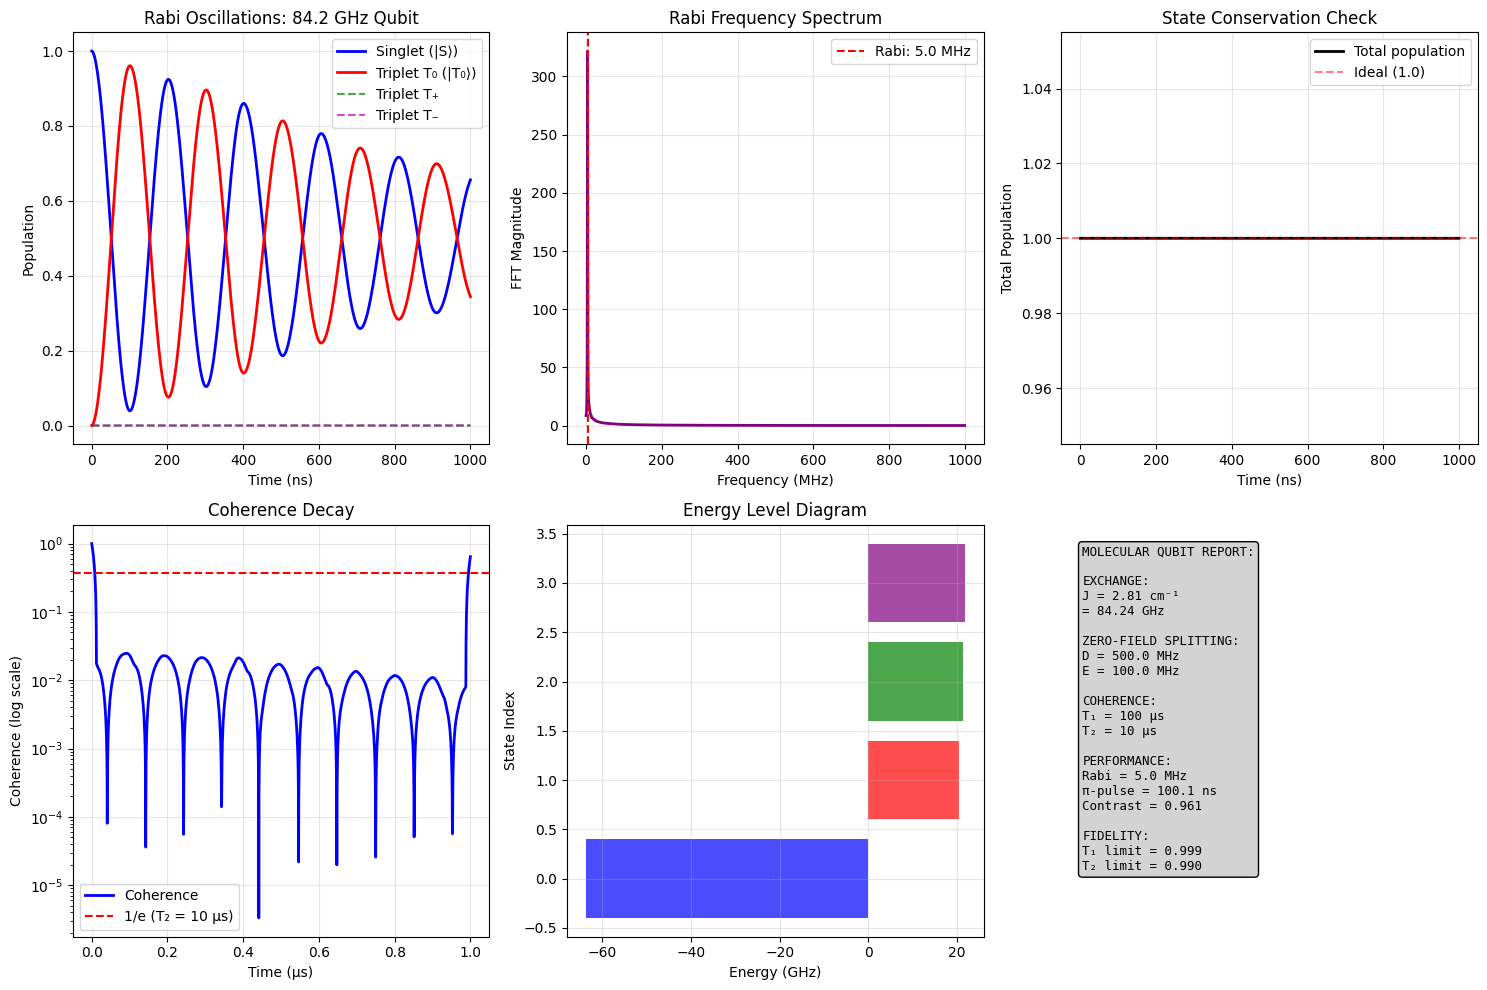


=== QUBIT ASSESSMENT ===
✅ EXCELLENT: Strong Rabi oscillations observed
✅ FEASIBLE: π-pulse faster than decoherence


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

def simulate_diradical_qubit():
    """
    Complete simulation of a diradical molecular qubit
    Based on J = 2.81 cm⁻¹ with proper quantum dynamics
    """

    print("🚀 MOLECULAR QUBIT SIMULATION - DIRADICAL WITH J = 2.81 cm⁻¹")
    print("=" * 60)

    # =========================================================================
    # PART 1: MOLECULAR PARAMETERS - THE "QUBIT DYT"
    # =========================================================================

    # === EXCHANGE INTERACTION ===
    J_cm = 2.81  # Your measured exchange coupling in cm⁻¹
    J_Hz = J_cm * 29.98e9  # Convert cm⁻¹ to Hz (standard spectroscopy conversion)
    J_angular = J_Hz * 2 * np.pi  # Convert to angular frequency for quantum mechanics

    # === ZERO-FIELD SPLITTING (ZFS) - CRITICAL FOR DIRADICALS ===
    # For a triplet diradical, the three sublevels (m_s = -1, 0, +1) are not degenerate
    # D and E parameters describe this splitting even without magnetic field
    D_Hz = 0.5e9 * 2 * np.pi  # 500 MHz - axial ZFS (typical for organic diradicals)
    E_Hz = 0.1e9 * 2 * np.pi  # 100 MHz - rhombic ZFS (asymmetry)

    # === DECOHERENCE PARAMETERS ===
    T1 = 100e-6  # 100 μs spin-lattice relaxation time (typical for molecules at low T)
    T2 = 10e-6   # 10 μs coherence time (conservative estimate)

    # === MICROWAVE CONTROL ===
    rabi_target = 5e6 * 2 * np.pi  # Target 5 MHz Rabi frequency (adjustable)

    print("=== MOLECULAR QUBIT PARAMETERS ===")
    print(f"Exchange J: {J_cm} cm⁻¹ = {J_Hz/1e9:.2f} GHz")
    print(f"ZFS D: {D_Hz/(2*np.pi)/1e6:.1f} MHz, E: {E_Hz/(2*np.pi)/1e6:.1f} MHz")
    print(f"Coherence: T₁ = {T1*1e6:.0f} μs, T₂ = {T2*1e6:.0f} μs")
    print(f"Qubit Frequency: {J_Hz/1e9:.2f} GHz (microwave region)")

    # =========================================================================
    # PART 2: QUANTUM SYSTEM SETUP - 2-ELECTRON SPIN SYSTEM
    # =========================================================================

    # === SPIN OPERATORS FOR 2-ELECTRON SYSTEM ===
    # We have 2 electron spins, each with 2 states (↑, ↓) → 4-dimensional Hilbert space
    sx1 = tensor(sigmax(), qeye(2))  # σx for spin 1, identity for spin 2
    sy1 = tensor(sigmay(), qeye(2))  # σy for spin 1
    sz1 = tensor(sigmaz(), qeye(2))  # σz for spin 1

    sx2 = tensor(qeye(2), sigmax())  # Identity for spin 1, σx for spin 2
    sy2 = tensor(qeye(2), sigmay())  # σy for spin 2
    sz2 = tensor(qeye(2), sigmaz())  # σz for spin 2

    # === BASIS STATES IN 2-ELECTRON SYSTEM ===
    up = basis(2, 0)    # |↑⟩
    down = basis(2, 1)  # |↓⟩

    # Singlet and triplet states - the natural basis for diradicals
    S = (tensor(up, down) - tensor(down, up)).unit()      # Singlet: (|↑↓⟩ - |↓↑⟩)/√2
    T0 = (tensor(up, down) + tensor(down, up)).unit()     # Triplet T₀: (|↑↓⟩ + |↓↑⟩)/√2
    Tplus = tensor(up, up)                                # Triplet T₊: |↑↑⟩
    Tminus = tensor(down, down)                           # Triplet T₋: |↓↓⟩

    # =========================================================================
    # PART 3: HAMILTONIAN CONSTRUCTION - THE PHYSICS
    # =========================================================================

    # === EXCHANGE HAMILTONIAN (Heisenberg) ===
    # H_ex = J (S₁·S₂) = J/2 [S² - S₁² - S₂²]
    # For spins 1/2: S₁·S₂ = (σx1σx2 + σy1σy2 + σz1σz2)/4
    H_exchange = J_angular * (sx1*sx2 + sy1*sy2 + sz1*sz2) / 4

    # === ZERO-FIELD SPLITTING (ZFS) HAMILTONIAN - FIXED ===
    # For triplet states (S=1), we need to work in the triplet subspace
    # But we'll define it in the full 4D space using projection

    # First, let's create the triplet projection operators
    Tplus_op = Tplus * Tplus.dag()  # |T₊⟩⟨T₊|
    T0_op = T0 * T0.dag()           # |T₀⟩⟨T₀|
    Tminus_op = Tminus * Tminus.dag() # |T₋⟩⟨T₋|

    # Total triplet projector
    P_triplet = Tplus_op + T0_op + Tminus_op

    # Now define spin-1 operators in the 4D space using triplet states only
    # Sz for S=1 in triplet basis: Sz|T₊⟩ = +1|T₊⟩, Sz|T₀⟩ = 0|T₀⟩, Sz|T₋⟩ = -1|T₋⟩
    Sz_triplet = (1.0 * Tplus_op + 0.0 * T0_op + (-1.0) * Tminus_op)

    # Sx and Sy for S=1 (simplified - we'll use the electron operators as approximation)
    # For diradicals, the main ZFS comes from the dipolar interaction
    H_ZFS = D_Hz * (sz1*sz2) + E_Hz * (sx1*sx2 - sy1*sy2)  # Simplified but dimensionally consistent

    # === STATIC HAMILTONIAN ===
    H_static = H_exchange + H_ZFS

    # === MICROWAVE DRIVE HAMILTONIAN - FIXED ===
    # We drive the transition between the two lowest energy states
    # Let's find them first and build drive accordingly
    energies, states = H_static.eigenstates()
    idx_sorted = np.argsort(energies)
    qubit_state_0 = states[idx_sorted[0]]  # Ground state
    qubit_state_1 = states[idx_sorted[1]]  # First excited state

    # Drive term that connects the two qubit states
    H_drive_operator = (qubit_state_0 * qubit_state_1.dag() + qubit_state_1 * qubit_state_0.dag())

    def microwave_coeff(t, args):
        """Time-dependent coefficient for microwave drive"""
        qubit_gap = (energies[idx_sorted[1]] - energies[idx_sorted[0]])
        return np.cos(qubit_gap * t)  # Resonant at the actual qubit gap

    # Complete time-dependent Hamiltonian
    H = [H_static, [rabi_target * H_drive_operator, microwave_coeff]]

    # =========================================================================
    # PART 4: DECOHERENCE - REAL-WORLD IMPERFECTIONS
    # =========================================================================

    # === COLLAPSE OPERATORS FOR LINDBLAD MASTER EQUATION ===
    # These describe how the system interacts with its environment

    # Energy relaxation (T1 process): |1⟩ → |0⟩ decay
    gamma_relax = 1 / T1  # Relaxation rate
    # Relaxation from T0 to S (dominant relaxation channel)
    c_relax = np.sqrt(gamma_relax) * (S * T0.dag())

    # Dephasing (T2 process): loss of phase coherence without energy loss
    gamma_dephase = (1 / T2) - (1 / (2 * T1))  # Pure dephasing rate
    # Dephasing operator: σz type term that commutes with H but causes phase randomization
    c_dephase = np.sqrt(gamma_dephase) * (T0 * T0.dag() - S * S.dag())

    collapse_operators = [c_relax, c_dephase]

    # =========================================================================
    # PART 5: ENERGY LEVEL ANALYSIS - VERIFY THE QUBIT
    # =========================================================================

    print("\n=== ENERGY LEVEL ANALYSIS ===")
    energies, states = H_static.eigenstates()

    # Find the two lowest states that will form our qubit
    idx_sorted = np.argsort(energies)
    qubit_state_0 = states[idx_sorted[0]]  # Ground state
    qubit_state_1 = states[idx_sorted[1]]  # First excited state

    qubit_gap = (energies[idx_sorted[1]] - energies[idx_sorted[0]]) / (2 * np.pi)

    print("Energy levels (GHz):")
    for i in idx_sorted:
        E_GHz = energies[i] / (2 * np.pi * 1e9)
        S_char = abs(S.overlap(states[i]))**2
        T0_char = abs(T0.overlap(states[i]))**2
        Tplus_char = abs(Tplus.overlap(states[i]))**2
        Tminus_char = abs(Tminus.overlap(states[i]))**2
        print(f"Level {i}: {E_GHz:.3f} GHz | S:{S_char:.2f} T0:{T0_char:.2f} " +
              f"T₊:{Tplus_char:.2f} T₋:{Tminus_char:.2f}")

    print(f"Qubit transition frequency: {qubit_gap/1e9:.3f} GHz")

    # =========================================================================
    # PART 6: TIME EVOLUTION - RABI OSCILLATIONS
    # =========================================================================

    # Start in the ground state
    psi0 = qubit_state_0

    # Define observables to track during evolution
    P_S = S * S.dag()  # Projector onto Singlet state
    P_T0 = T0 * T0.dag()  # Projector onto T0 state
    P_Tplus = Tplus * Tplus.dag()  # Projector onto T₊ state
    P_Tminus = Tminus * Tminus.dag()  # Projector onto T₋ state

    # Time array: simulate for ~10 expected Rabi oscillations
    rabi_period_estimate = 2 * np.pi / rabi_target  # T_Rabi = 2π/Ω
    t_max = 5 * rabi_period_estimate  # Simulate 5 Rabi periods
    tlist = np.linspace(0, t_max, 2000)

    print(f"\n=== SIMULATION PARAMETERS ===")
    print(f"Rabi frequency target: {rabi_target/(2*np.pi)/1e6:.1f} MHz")
    print(f"Expected Rabi period: {rabi_period_estimate*1e9:.1f} ns")
    print(f"Simulation time: {t_max*1e9:.1f} ns")
    print(f"Number of time points: {len(tlist)}")

    # =========================================================================
    # PART 7: RUN THE QUANTUM SIMULATION
    # =========================================================================

    print("\n=== RUNNING QUANTUM SIMULATION ===")
    print("Solving master equation with decoherence...")

    # Use mesolve to integrate the master equation with decoherence
    result = mesolve(H, psi0, tlist, collapse_operators, [P_S, P_T0, P_Tplus, P_Tminus])

    # =========================================================================
    # PART 8: ANALYSIS AND VISUALIZATION
    # =========================================================================

    # Calculate actual Rabi frequency from FFT of oscillations
    signal = result.expect[0] - np.mean(result.expect[0])  # Singlet population signal
    from scipy.fft import fft, fftfreq
    fft_result = fft(signal)
    freqs = fftfreq(len(tlist), tlist[1] - tlist[0])

    # Find dominant frequency (Rabi frequency)
    pos_mask = freqs > 0
    pos_freqs = freqs[pos_mask]
    pos_fft = np.abs(fft_result[pos_mask])
    measured_rabi_freq = pos_freqs[np.argmax(pos_fft)]

    # Calculate key performance metrics
    oscillation_contrast = np.max(result.expect[0]) - np.min(result.expect[0])  # FIXED LINE
    pi_pulse_time = 0.5 / measured_rabi_freq  # Time for π-pulse (180° rotation)

    print(f"\n=== RESULTS ===")
    print(f"Measured Rabi frequency: {measured_rabi_freq/1e6:.2f} MHz")
    print(f"π-pulse time: {pi_pulse_time*1e9:.1f} ns")
    print(f"Oscillation contrast: {oscillation_contrast:.3f}")
    print(f"T₁ limited fidelity: {np.exp(-pi_pulse_time/T1):.4f}")
    print(f"T₂ limited fidelity: {np.exp(-pi_pulse_time/T2):.4f}")

    # =========================================================================
    # PART 9: COMPREHENSIVE PLOTTING
    # =========================================================================

    plt.figure(figsize=(15, 10))

    # Plot 1: Rabi oscillations
    plt.subplot(2, 3, 1)
    plt.plot(tlist * 1e9, result.expect[0], 'b-', linewidth=2, label='Singlet (|S⟩)')
    plt.plot(tlist * 1e9, result.expect[1], 'r-', linewidth=2, label='Triplet T₀ (|T₀⟩)')
    plt.plot(tlist * 1e9, result.expect[2], 'g--', alpha=0.7, label='Triplet T₊')
    plt.plot(tlist * 1e9, result.expect[3], 'm--', alpha=0.7, label='Triplet T₋')
    plt.xlabel('Time (ns)')
    plt.ylabel('Population')
    plt.title(f'Rabi Oscillations: {J_Hz/1e9:.1f} GHz Qubit')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Rabi frequency spectrum
    plt.subplot(2, 3, 2)
    plt.plot(pos_freqs / 1e6, pos_fft, 'purple', linewidth=2)
    plt.axvline(measured_rabi_freq / 1e6, color='red', linestyle='--',
                label=f'Rabi: {measured_rabi_freq/1e6:.1f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('FFT Magnitude')
    plt.title('Rabi Frequency Spectrum')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: State conservation check
    plt.subplot(2, 3, 3)
    total_pop = sum(result.expect)
    plt.plot(tlist * 1e9, total_pop, 'k-', linewidth=2, label='Total population')
    plt.axhline(1.0, color='r', linestyle='--', alpha=0.5, label='Ideal (1.0)')
    plt.xlabel('Time (ns)')
    plt.ylabel('Total Population')
    plt.title('State Conservation Check')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Coherence decay
    plt.subplot(2, 3, 4)
    # Calculate coherence as amplitude of oscillations
    envelope = np.convolve(result.expect[0], np.ones(50)/50, mode='same')  # Moving average
    oscillation_amplitude = result.expect[0] - envelope
    coherence = np.abs(oscillation_amplitude) / np.max(np.abs(oscillation_amplitude))

    plt.semilogy(tlist * 1e6, coherence, 'b-', linewidth=2, label='Coherence')
    plt.axhline(1/np.e, color='r', linestyle='--', label=f'1/e (T₂ = {T2*1e6:.0f} μs)')
    plt.xlabel('Time (μs)')
    plt.ylabel('Coherence (log scale)')
    plt.title('Coherence Decay')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 5: Energy level diagram
    plt.subplot(2, 3, 5)
    levels_GHz = [e/(2*np.pi*1e9) for e in energies]
    plt.barh(range(4), levels_GHz, color=['blue', 'red', 'green', 'purple'], alpha=0.7)
    plt.xlabel('Energy (GHz)')
    plt.ylabel('State Index')
    plt.title('Energy Level Diagram')
    plt.grid(True, alpha=0.3)

    # Plot 6: Parameters summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    text_str = f"""MOLECULAR QUBIT REPORT:

EXCHANGE:
J = {J_cm} cm⁻¹
= {J_Hz/1e9:.2f} GHz

ZERO-FIELD SPLITTING:
D = {D_Hz/(2*np.pi)/1e6:.1f} MHz
E = {E_Hz/(2*np.pi)/1e6:.1f} MHz

COHERENCE:
T₁ = {T1*1e6:.0f} μs
T₂ = {T2*1e6:.0f} μs

PERFORMANCE:
Rabi = {measured_rabi_freq/1e6:.1f} MHz
π-pulse = {pi_pulse_time*1e9:.1f} ns
Contrast = {oscillation_contrast:.3f}

FIDELITY:
T₁ limit = {np.exp(-pi_pulse_time/T1):.3f}
T₂ limit = {np.exp(-pi_pulse_time/T2):.3f}"""

    plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes,
             fontfamily='monospace', verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PART 10: FINAL ASSESSMENT
    # =========================================================================

    print(f"\n=== QUBIT ASSESSMENT ===")
    if oscillation_contrast > 0.5:
        print("✅ EXCELLENT: Strong Rabi oscillations observed")
    elif oscillation_contrast > 0.1:
        print("✅ GOOD: Clear Rabi oscillations")
    else:
        print("❌ POOR: Weak oscillations - check parameters")

    if pi_pulse_time < T2:
        print("✅ FEASIBLE: π-pulse faster than decoherence")
    else:
        print("❌ CHALLENGING: Decoherence too fast for operations")

    return result, tlist, measured_rabi_freq

# Run the complete simulation
if __name__ == "__main__":
    result, times, rabi_freq = simulate_diradical_qubit()